In [1]:
""" Check the trees GPP and GPP per LAI response during water table drawdown (Jul-Sep)
    But it seems this is not as illustrative as XR relative to GPP
"""
import numpy as np
import os
import pandas as pd
import xarray as xr
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 14

prefix_default = '20231116'
prefix_uptake = '20240327'
prefix_list = [prefix_default, prefix_uptake] # , '20240316_2']

pft_names = ['Spruce', 'Tamarack', 'Shrub']

chambers_ordered = {
    'amb': ['7', '6', '20', '13', '8', '17'],
    'elev': ['19', '11', '4', '16', '10']
}

xticklabels = ['TAMB', 'T0.00', 'T2.25','T4.50', 'T6.75', 'T9.00', 
               'T0.00CO2', 'T2.25CO2', 'T4.5CO2', 'T6.75CO2', 'T9.00CO2']

pftfrac = [0.36, 0.14, 0.25]

data_collect = {}
for prefix in prefix_list:
    filename = os.path.join(
        os.environ['PROJDIR'], 'ELM_Phenology', 'output', 'extract', prefix, 
        'analysis_ts.csv'
    )
    data = pd.read_csv(filename, index_col = 0, header = [0,1,2,3], parse_dates=True)

    # filter to growing season during one year with drawdown, and one year without
    # late summer: Jul-Sep
    data = data.loc[(data.index.month >= 8) & (data.index.month <= 8), :].resample('1Y').mean()
    data.index = data.index.year

    # average hummock and hollow
    data.columns = data.columns.reorder_levels([3,0,1,2])
    data = data.sort_index(axis = 1)
    data = data.loc[:, 'hummock'] * 0.64 + data.loc[:, 'hollow'] * 0.36

    # reorder
    data = data.loc[:, chambers_ordered['amb'] + chambers_ordered['elev']]

    data_collect[prefix] = data

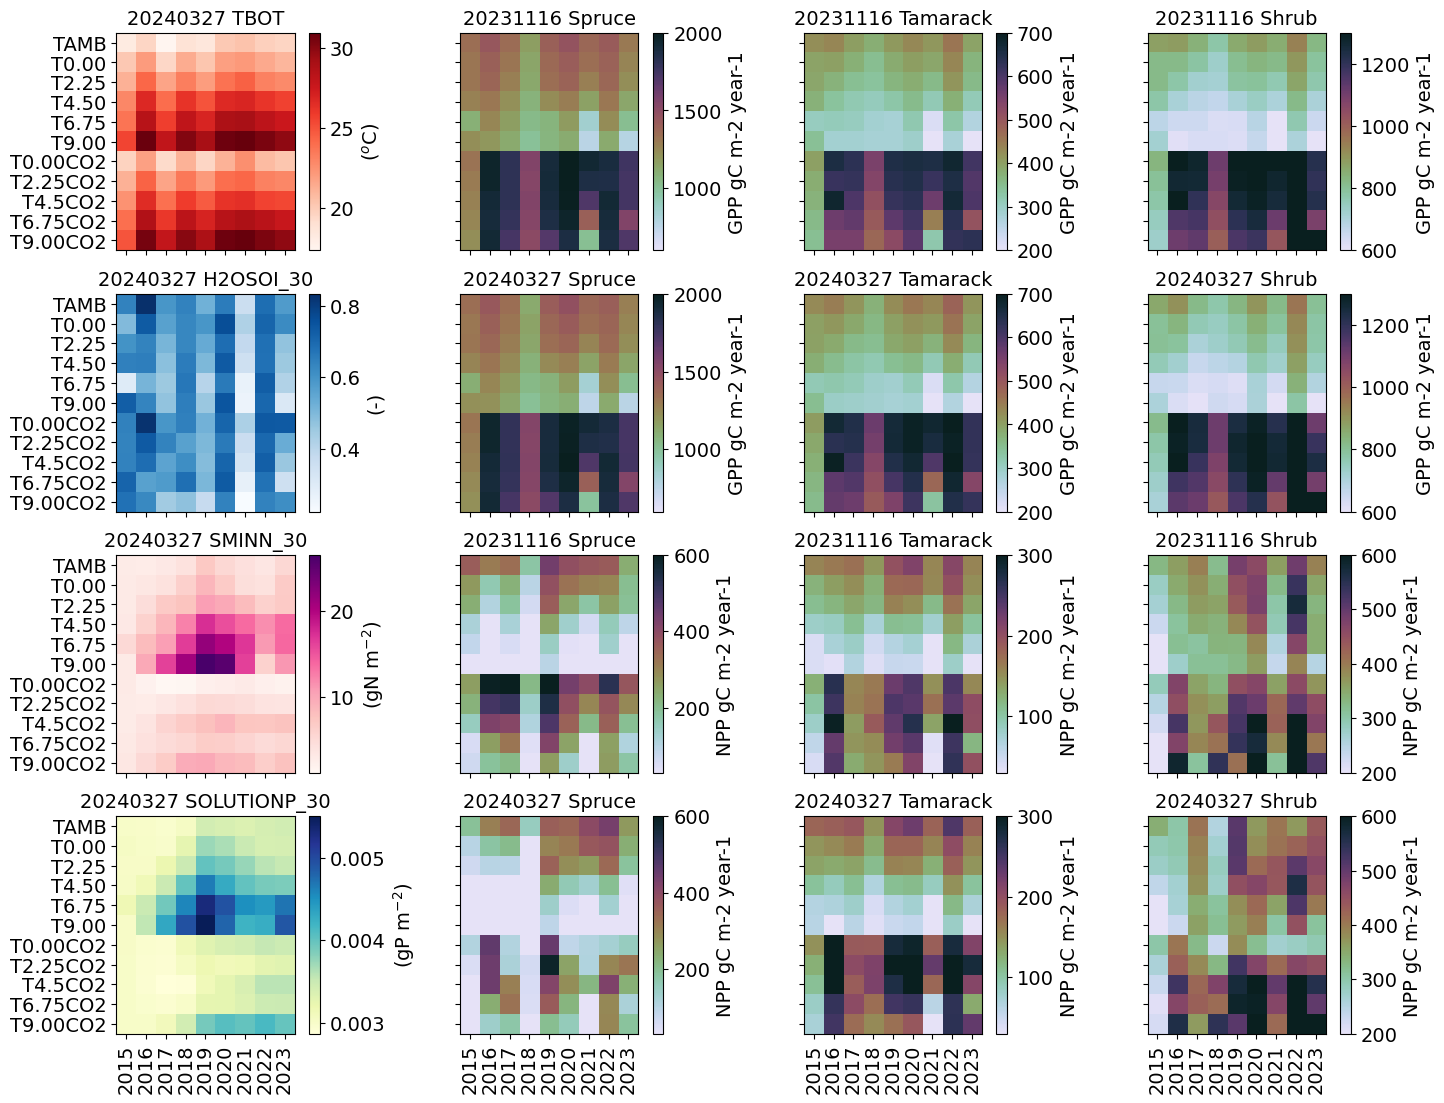

In [2]:
# note ZWT are converted all relative to hollow surface, negative => downwards
fig, axes = plt.subplots(4, 4, figsize = (17, 13), sharex = True, sharey = True)
fig.subplots_adjust()

for j, varname in enumerate(['TBOT', 'H2OSOI_30', 'SMINN_30', 'SOLUTIONP_30']):
    if varname == 'H2OSOI_30':
        cmap = 'Blues'
        label = '(-)'
    elif varname == 'TBOT':
        cmap = 'Reds'
        label = '($^o$C)'
    elif varname == 'SMINN_30':
        cmap = 'RdPu'
        label = '(gN m$^{-2}$)'
    elif varname == 'SOLUTIONP_30':
        cmap = 'YlGnBu'
        label = '(gP m$^{-2}$)'

    ax = axes[j, 0]
    cf = ax.imshow(data.loc[:, (slice(None), varname, '0')].values.T, cmap = cmap)
    ax.set_xticks(range(len(data.index)))
    ax.set_xticklabels(data.index, rotation = 90)
    ax.set_yticks(range(len(chambers_ordered['amb']) + len(chambers_ordered['elev'])))
    ax.set_yticklabels(xticklabels)
    plt.colorbar(cf, ax = ax, label = label)
    ax.set_title(f'{prefix} {varname}')

""" GPP sensitivity of the plants are almost the same. 
NPP is different - pointing to respiratory loss changes. Spruce and Shrub has notably lower productivity at T0.00CO2, while Tamarack higher. Therefore, the new scheme increased the plants' sensitivity to nutrient availability changes. 
"""
palette = sns.cubehelix_palette(n_colors = 256, start=2, rot=1.5, dark=0.1, light=0.9, as_cmap=True)

# note ZWT are converted all relative to hollow surface, negative => downwards
for k, varname in enumerate(['GPP', 'NPP']):
    for i, pft in enumerate(['2', '3', '11'], 1):

        if varname == 'GPP':
            if pft == '2':
                vmin, vmax = 600, 2000
            elif pft == '3':
                vmin, vmax = 200, 700
            else:
                vmin, vmax = 600, 1300
        else:
            if pft == '2':
                vmin, vmax = 30, 600
            elif pft == '3':
                vmin, vmax = 30, 300
            else:
                vmin, vmax = 200, 600

        for j, prefix in enumerate(prefix_list):
            ax = axes[2*k + j, i]

            data = data_collect[prefix]

            cf = ax.imshow(data.loc[:, (slice(None), varname, pft)].values.T * 365 * 86400 * \
                           pftfrac[i-1], cmap = palette, vmax = vmax, vmin = vmin)
            #cf = ax.imshow(data.loc[:, (slice(None), varname, pft)].values.T * 365 * 86400 / \
            #               data.loc[:, (slice(None), 'TLAI', pft)].values.T, 
            #               cmap = palette)

            ax.set_xticks(range(len(data.index)))
            ax.set_xticklabels(data.index, rotation = 90)
            ax.set_yticks(range(len(chambers_ordered['amb']) + len(chambers_ordered['elev'])))
            ax.set_yticklabels(xticklabels)
            plt.colorbar(cf, ax = ax, label = varname + ' gC m-2 year-1')
            ax.set_title(f'{prefix} {pft_names[i-1]}')